<a href="https://colab.research.google.com/github/macine-git/Introductive-ML-Projects/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRACTICAL N°1: LINEAR REGRESSION**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# For linear regression
import statsmodels.api as sm

# To handle csv import
import pandas as pd

# TRAINING: POLYNOMIAL REGRESSION

The training part of the practical is dedicated to the study of polynomial regression, as was presented during the lecture.

## Data generation

We let $f : [-1,1] \to \mathbb{R}$ be defined by $f(x) = 1 + 3x - 4.5x^3 + x^5 + x^8$. The graph of $f$ is plotted below.


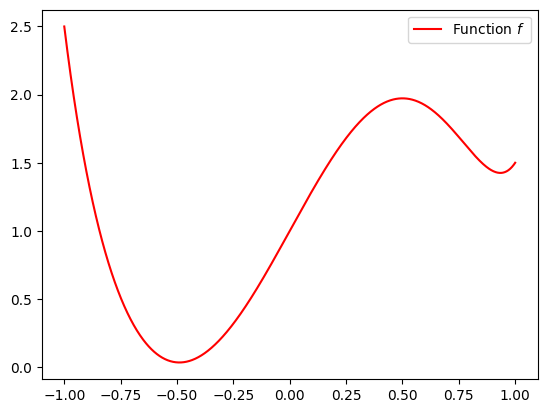

In [2]:
def f(x):
  return 1 + 3 * x - 4.5 * x**3 + x**5 + x**8

n_plot = 1000
x_plot = np.linspace(-1, 1, n_plot)
y_plot = f(x_plot)

plt.plot(x_plot, y_plot, 'r-', label="Function $f$")
plt.legend()
plt.show()

We now generate a sample $(x_i,y_i)_{1 \leq i \leq n}$ of noisy data. To proceed,


*   we draw independent and uniformly distributed points $x_i \in [-1,1]$;
*   we draw independent errors $\epsilon_i \sim \mathcal{N}(0,\sigma^2)$;
*   we set $y_i = f(x_i) + \epsilon_i$.

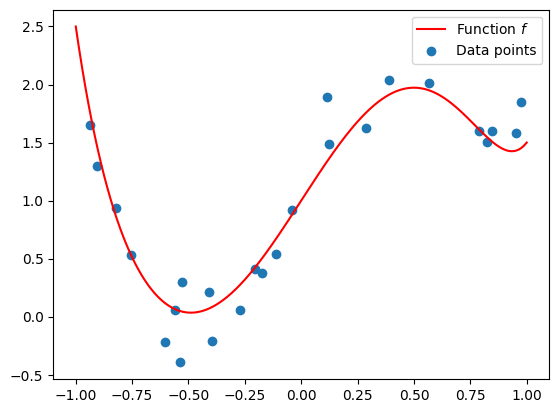

In [ ]:
n_sample = 25 # Number of data points
sigma = 0.2   # Standard deviation of the noise

# Setting random seed for reproducibility
np.random.seed(2026)

# Draw independent and uniformly distributed points x_i in [-1,1]
x_sample = np.random.uniform(-1, 1, n_sample)

# Draw independent and normally distributed errors epsilon_i ~ N(0, sigma^2)
epsilon = np.random.normal(0, sigma, n_sample)

# Set y_i = f(x_i) + epsilon_i
y_sample = f(x_sample) + epsilon

# Plotting the noisy data alongside the original function
plt.plot(x_plot, y_plot, 'r-', label="Function $f$")
plt.scatter(x_sample, y_sample, label="Data points")
plt.legend()
plt.show()

## Polynomial regression

Given the sample $(x_i,y_i)_{1 \leq i \leq n}$, and an integer $p \geq 0$, the OLS is the vector $\hat{\beta} \in \mathbb{R}^{p+1}$ which minimises the function $$\beta \in \mathbb{R}^{p+1} \mapsto \sum_{i=1}^n \left(y_i - (\beta_0 + \beta_1 x_i + \cdots + \beta_p x_i^p)\right)^2.$$

It is computed using the package `statsmodel`, in particular with the command `sm.OLS(y, X).fit()` which requires the construct the design matrix $X \in \mathbb{R}^{n \times (p+1)}$, with coefficients $x_i^j$.

**Question:** complete the function `polynomial_design_matrix(x,p)`, which takes a one-dimensional array `x` and an integer `p`, and returns a two-dimensional array with coefficients `x[i]**j`.

In [ ]:
def polynomial_design_matrix(x,p):
  Finaltab=[]
  for i in range (len(x)):
    Intertab=[]
    for j in range (p+1):
      Intertab.append(x[i]**j)
    Finaltab.append(Intertab)
  return np.array(Finaltab)




The application of `sm.OLS(y, X).fit()` now works as follows.

In [ ]:
p_test = 3 # Polynomial of degree 3
X_test = polynomial_design_matrix(x_sample,p_test)

# Application of linear regression
model = sm.OLS(y_sample, X_test).fit()

# R^2, AIC, BIC
print("R2:", model.rsquared)
print("AIC:", model.aic)
print("BIC:", model.bic)

R2: 0.881900267515885
AIC: 12.683720929968324
BIC: 17.559224229441128


**Question:** for $p$ ranging from $0$ to $p_\mathrm{max}=10$, plot the values of $R^2$, AIC and BIC as a function of $p$.

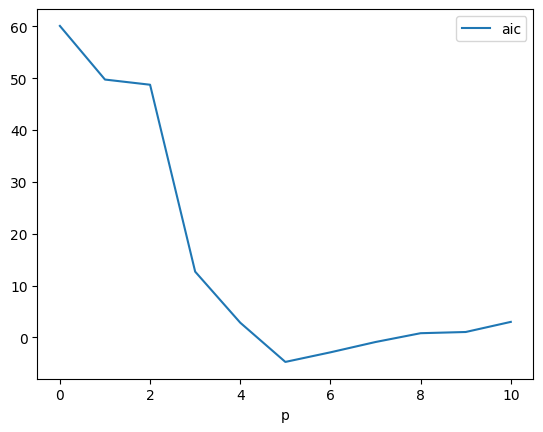

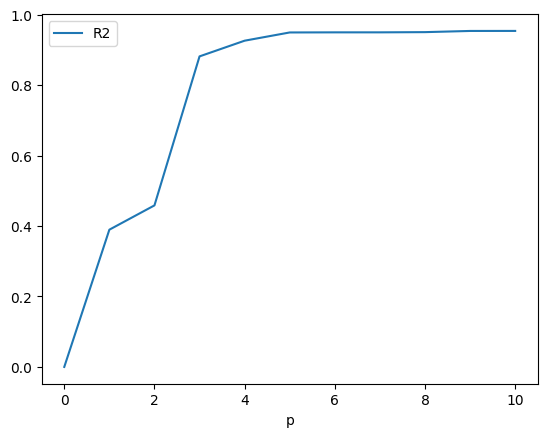

Text(0.5, 0, 'p')

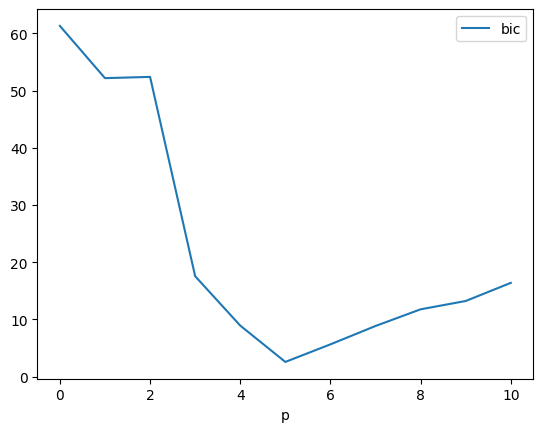

In [ ]:
p_max = 10
r2_values = []
aic_values = []
bic_values = []
p_values=[i for i in range (p_max+1)]
for i in range (p_max+1):
  X_test = polynomial_design_matrix(x_sample,i)
  model = sm.OLS(y_sample, X_test).fit()
  r2_values.append(model.rsquared)
  aic_values.append(model.aic)
  bic_values.append(model.bic)
plt.xlabel("p")
plt.plot(p_values,aic_values,label="aic")
plt.legend()
plt.show()
plt.xlabel("p")
plt.plot(p_values,r2_values,label="R2")
plt.legend()
plt.xlabel("p")
plt.show()
plt.plot(p_values,bic_values,label="bic")
plt.legend()
plt.xlabel("p")

## Prediction

Once the vector $\hat{\beta} \in \mathbb{R}^{p+1}$ is estimated, we want to plot the function $\hat{f} : x \mapsto \hat{\beta}_0 + \hat{\beta}_1 x + \cdots + \hat{\beta}_p x^p$. There are two possible ways to do so:

*   using the values of the coefficients of $\hat{\beta}$ stored in `model.params`;
*   using the function `model.predict()`.

They are described below.

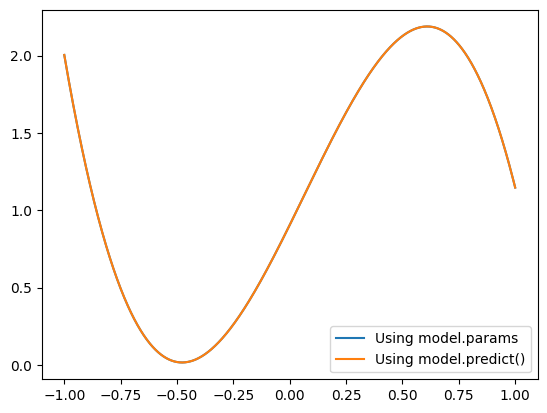

In [ ]:
p_test = 3 # Polynomial of degree 3
X_test = polynomial_design_matrix(x_sample,p_test)

# Application of linear regression
model = sm.OLS(y_sample, X_test).fit()

# For both methods, we need to construct the matrix with coefficients x_i^j,
# x_i in the vector x_plot

X_plot = polynomial_design_matrix(x_plot,p_test)

# Using model.params
y_pred_1 = np.zeros(n_plot)
for i in range(n_plot):
  y_pred_1[i] = np.dot(model.params,X_plot[i, :])

plt.plot(x_plot, y_pred_1, label="Using model.params")

# Using model.predict
y_pred_2 = model.predict(X_plot)

plt.plot(x_plot, y_pred_2, label="Using model.predict()")

plt.legend()
plt.show()

**Question:** on the same figure, plot the graph of the function $\hat{f}$ for $p$ ranging from $0$ to $p_\mathrm{max}$.

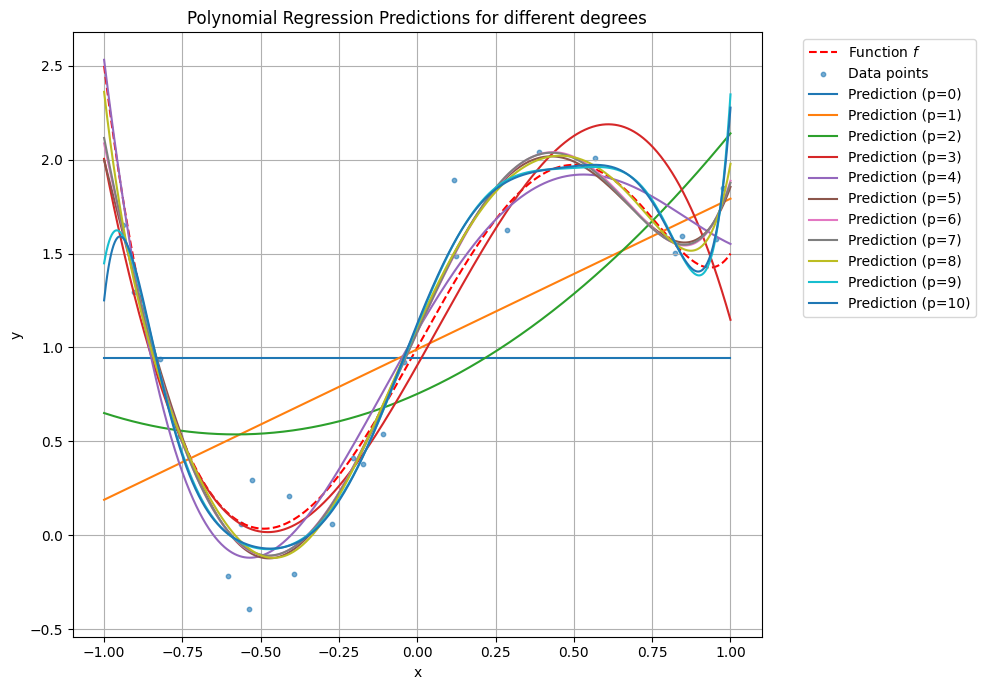

In [ ]:
p_max = 10

plt.figure(figsize=(10, 7))
plt.plot(x_plot, y_plot, 'r--', label="Function $f$")
plt.scatter(x_sample, y_sample, label="Data points", s=10, alpha=0.6)

for p in range(p_max + 1):
  # Fit a new model for each p
  X_sample_p = polynomial_design_matrix(x_sample, p)
  model_p = sm.OLS(y_sample, X_sample_p).fit()

  # Generate X_plot for the current p
  X_plot_p = polynomial_design_matrix(x_plot, p)

  # Predict using the model fitted for the current p
  y_pred_p = model_p.predict(X_plot_p)

  plt.plot(x_plot, y_pred_p, label=f"Prediction (p={p})")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Polynomial Regression Predictions for different degrees")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.tight_layout()
plt.show()

# APPLICATION: VARIABLE SELECTION

The second part of this tutorial deals with the prediction of ozone concentration.

## Importing data

We will work with the file `LAozone.csv`. These data record the level of atmospheric ozone concentration from eight daily meteorological measurements made in the Los Angeles basin in 1976. Although measurements were made every day that year, some observations were missing; here we have the 330 complete cases. The response, referred to as ozone,
is actually the log of the daily maximum of the hourly-average ozone
concentrations in Upland, California.

You first have to download the `LAozone.csv` from [Educnet](https://educnet.enpc.fr/course/view.php?id=1772).

* If you are using a local version of Jupyter: define the path of the folder which contains the csv file in the string `repert`; typically with Linux or Mac:
`repert = '/Users/Documents/'`
and with Windows:
`repert = 'c:/Users/Documents/'`
then execute the next block:

In [ ]:
repert = '/content/' # for example, to modify if different
dataset = pd.read_table(repert+'LAozone.csv', sep=',', decimal='.')

* If you are using Google Colab: click on the Folder icon on your left and upload the csv file, then execute the next block:

In [ ]:
# Put the dataset into a pandas DataFrame
dataset = pd.read_table('LAozone.csv', sep=',', decimal='.')

In any case, the dataset should now be loaded as a DataFrame:

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ozone     330 non-null    int64
 1   vh        330 non-null    int64
 2   wind      330 non-null    int64
 3   humidity  330 non-null    int64
 4   temp      330 non-null    int64
 5   ibh       330 non-null    int64
 6   dpg       330 non-null    int64
 7   ibt       330 non-null    int64
 8   vis       330 non-null    int64
 9   doy       330 non-null    int64
dtypes: int64(10)
memory usage: 25.9 KB


In this dataset, each row corresponds to an observation. The variables are:
* ozone : Upland Maximum Ozone
* vh : Vandenberg 500 mb Height
* wind : Wind Speed (mph)
* humidity : Humidity (%)
* temp : Sandburg AFB Temperature
* ibh : Inversion Base Height
* dpg : Daggot Pressure Gradient
* ibt : Inversion Base Temperature
* vis : Visibility (miles)
* doy : Day of the Year

We visualise the first rows of the dataset.

In [ ]:
dataset.head()

,ozone,vh,wind,humidity,temp,ibh,dpg,ibt,vis,doy
0,3,5710,4,28,40,2693,-25,87,250,3
1,5,5700,3,37,45,590,-24,128,100,4
2,5,5760,3,51,54,1450,25,139,60,5
3,6,5720,4,69,35,1568,15,121,60,6
4,4,5790,6,19,45,2631,-33,123,100,7


We define the DataFrame `X`, which contains the values of the predictors (including the intercept), and the Series `y`, which contains the values of the response variable.

In [ ]:
predictors = ['vh','wind','humidity','temp','ibh','dpg','ibt','vis']
X = dataset[predictors]
X = sm.add_constant(X) # Adding the intercept: this creates a colmun called 'const' in X
y = dataset['ozone'] # Response variable

Linear regression with all predictors is applied as follows.

In [ ]:
complete_model = sm.OLS(y, X).fit()

print("R2:", complete_model.rsquared)

## Variable selection

We recall the principle of the forward and backward variable selection algorithms, given an information criterion IC which is either AIC or BIC.

For the forward algorithm, you start with only the intercept. Then you test linear regression with a single predictor, and take the one which returns the smallest IC. If this IC is smaller than the one for linear regression with only the interecept, then you include the predictor in your model. You then restart the procedure, and stops when the value of IC ceases to decrease, or when all predictors are included in the model.

The backward algorithm starts with all predictors and, at each step, removes the predictor whose removal makes the IC decrease the most (it does not try to remove the intercept). It stops when the IC ceases to decrease, or when there is no more predictor in the model.

**Question:** implement the two algorithms, with both AIC and BIC. Which predictors are selected by each algorithms? What do you conclude? In order to present your results, you may draw the evolution of the IC as a function of the number of parameters for each algorithm.

In [ ]:
# Your code here